## Import Packages


In [8]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns',100)

## Loading data

In [9]:
train=pd.read_pickle('../data/train_engineered.pkl')


In [10]:
test=pd.read_pickle('../data/train_engineered.pkl')

In [11]:
train.shape

(590540, 453)

In [12]:
test.shape

(590540, 453)

## Baseline Features for Analysis 

In [13]:
baseline_features = [
    "TransactionAmt",
    "TransactionAmt_log",
    "ProductCD",
    "card1",
    "card2",
    "card3",
    "card4",
    "card5",
    "card6",
    "addr1",
    "addr2",
    "dist1",
    "dist2",
    "P_emaildomain_group",
    "R_emaildomain_group",
    "P_emaildomain_suffix",
    "R_emaildomain_suffix",
    "match_email",
    "browser_group",
    "os_group",
    "DeviceType",
    "C1",
    "C2",
    "C13",
    "D1",
    "D10",
    "D15",
    "TransactionAmt_to_mean_card1",
    "TransactionAmt_to_std_card1",
    "TransactionAmt_to_mean_card4",
    "TransactionAmt_to_std_card4"
]

## Dependent & Independent Variables

In [14]:
X = train[baseline_features].copy()
y = train['isFraud'].copy()

## Encode categorical columns

In [15]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])

## Impute missing values

In [16]:
imputer = SimpleImputer(strategy="median")

X_imputed = pd.DataFrame(imputer.fit_transform(X),columns=X.columns)

## Train-Validation-Test split

In [17]:
#First split: 60% train and 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(X_imputed, y, test_size=0.4, random_state=42, stratify=y)

X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)


print(f'X Train Data: {X_train.shape}')
print(f'X Validation Data: {X_valid.shape}')
print(f'X Test Data: {X_test.shape}')

print("\n Train Distribution")
print(y_train.value_counts(normalize=True)*100)
print("\n Validation Distribution")
print(y_valid.value_counts(normalize=True)*100)
print("\n Test Distribution")
print(y_test.value_counts(normalize=True)*100)

X Train Data: (354324, 31)
X Validation Data: (118108, 31)
X Test Data: (118108, 31)

 Train Distribution
isFraud
0    96.500943
1     3.499057
Name: proportion, dtype: float64

 Validation Distribution
isFraud
0    96.50066
1     3.49934
Name: proportion, dtype: float64

 Test Distribution
isFraud
0    96.501507
1     3.498493
Name: proportion, dtype: float64


## Evaluation Function 

In [18]:
model_results = []

def evaluate_model(model_name, model, X_data, y_data, dataset_name="Validation"):
    
    y_pred = model.predict(X_data)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_data)[:, 1]
        roc_auc = roc_auc_score(y_data, y_proba)
    else:
        roc_auc = np.nan

    accuracy = accuracy_score(y_data, y_pred)
    precision = precision_score(y_data, y_pred)
    recall = recall_score(y_data, y_pred)
    f1 = f1_score(y_data, y_pred)

    print(f"Model: {model_name}")
    print(f"Dataset: {dataset_name}")
    print("=" * 40)
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")
    print(f"ROC AUC: {roc_auc}")

    print("\nClassification Report:")
    print(classification_report(y_data, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_data, y_pred)
    plt.title(f"Confusion Matrix - {model_name} ({dataset_name})")
    plt.show()

    model_results.append({
        "Model": model_name,
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })

## XGBoost Starter Model

In [19]:
xgb_model=XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, 
                        eval_metric='logloss', n_jobs=-1,random_state=-1)
xgb_model.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


Model: XG-Boost Classification Starter
Dataset: Validation
Accuracy: 0.9761912825549497
Precision: 0.885131195335277
Recall: 0.3672876844906847
F1 Score: 0.5191518467852257
ROC AUC: 0.9201286697458655

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.89      0.37      0.52      4133

    accuracy                           0.98    118108
   macro avg       0.93      0.68      0.75    118108
weighted avg       0.97      0.98      0.97    118108



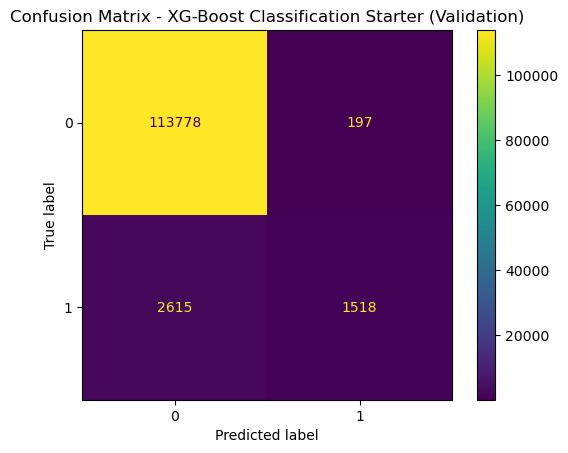

In [81]:
evaluate_model("XG-Boost Classification Starter", xgb_model, X_valid, y_valid)

## XGBoost GridSearchCV

In [21]:
xgb_param_grid = {
    "n_estimators" : [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.08],
    "subsample": [0.5, 0.8],
    "colsample_bytree": [0.5, 0.8]
}

In [22]:
xgb_grid = GridSearchCV(estimator = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
                        param_grid = xgb_param_grid, scoring='roc_auc', cv=3, n_jobs=-1, verbose=2)

xgb_grid.fit(X_train, y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.5, 0.8], 'learning_rate': [0.05, 0.08], 'max_depth': [3, 5], 'n_estimators': [100, 200], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


[CV] END colsample_bytree=0.5, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   2.5s
[CV] END colsample_bytree=0.5, learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.5; total time=   3.6s
[CV] END colsample_bytree=0.5, learning_rate=0.05, max_depth=5, n_estimators=200, subsample=0.8; total time=   4.1s
[CV] END colsample_bytree=0.5, learning_rate=0.08, max_depth=3, n_estimators=100, subsample=0.8; total time=   1.9s
[CV] END colsample_bytree=0.5, learning_rate=0.08, max_depth=5, n_estimators=100, subsample=0.5; total time=   2.6s
[CV] END colsample_bytree=0.5, learning_rate=0.08, max_depth=5, n_estimators=200, subsample=0.5; total time=   4.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   2.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estimators=100, subsample=0.5; total time=   2.6s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, n_estima

In [23]:
print(f'Best XGBoost Parameters \n {xgb_grid.best_params_}')
print(f'Best XGBoost CV ROC AUC \n {xgb_grid.best_score_}')

Best XGBoost Parameters 
 {'colsample_bytree': 0.8, 'learning_rate': 0.08, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best XGBoost CV ROC AUC 
 0.9036942197910033


Model: XGB Classifier Tuned
Dataset: Validation
Accuracy: 0.9752006637992346
Precision: 0.868421052631579
Recall: 0.3433341398499879
F1 Score: 0.4921102826426218
ROC AUC: 0.9067102787142175

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.87      0.34      0.49      4133

    accuracy                           0.98    118108
   macro avg       0.92      0.67      0.74    118108
weighted avg       0.97      0.98      0.97    118108



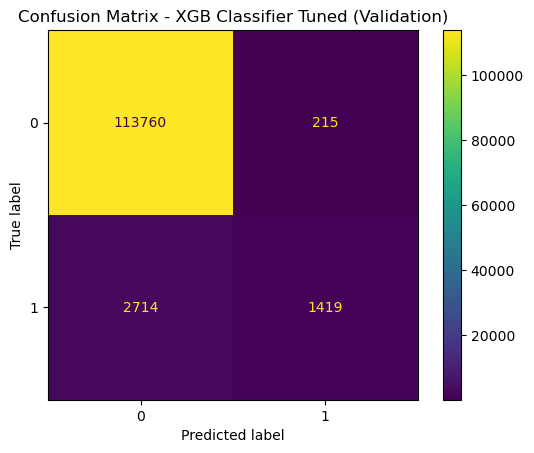

In [80]:
best_xgb_model = xgb_grid.best_estimator_


evaluate_model('XGB Classifier Tuned', best_xgb_model, X_valid, y_valid)

## LightGMB Starter Model

In [27]:
lgbm_model = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, 
                            class_weight='balanced', random_state=42, n_jobs=-1)

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 12398, number of negative: 341926
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012449 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4445
[LightGBM] [Info] Number of data points in the train set: 354324, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Model: LightGMB Classifier
Dataset: Validation
Accuracy: 0.8883987536830698
Precision: 0.20876786404016995
Recall: 0.7846600532300992
F1 Score: 0.3297910204911781
ROC AUC: 0.9221701447277242

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94    113975
           1       0.21      0.78      0.33      4133

    accuracy                           0.89    118108
   macro avg       0.60      0.84      0.63    118108
weighted avg       0.96      0.89      0.92    118108



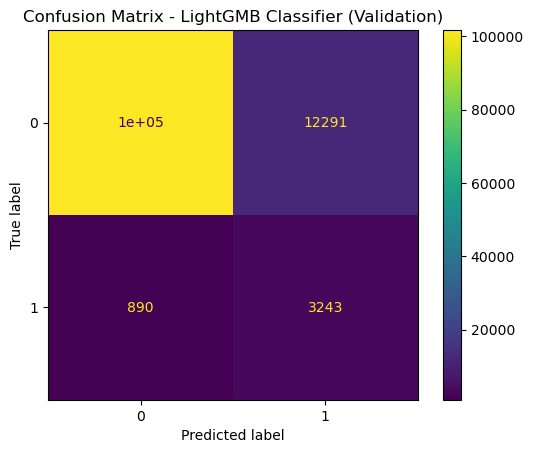

In [28]:
evaluate_model("LightGMB Classifier", lgbm_model, X_valid, y_valid, "Validation")

## LightGMB Grid Search

In [37]:
lgbm_param_grid={
    "n_estimators":[100,200],
    "learning_rate": [0.05, 0.08],
    "num_leaves":[29, 61],
    "max_dept": [3,6]
}

In [44]:
lgbm_grid = GridSearchCV(
    estimator = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid = lgbm_param_grid,
    scoring = 'roc_auc',
    n_jobs = -1
)

In [45]:
lgbm_grid.fit(X_train, y_train)

[LightGBM] [Warning] Unknown parameter: max_dept
[LightGBM] [Warning] Unknown parameter: max_dept
[LightGBM] [Info] Number of positive: 12398, number of negative: 341926
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013856 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4445
[LightGBM] [Info] Number of data points in the train set: 354324, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,estimator,LGBMClassifie...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.08], 'max_dept': [3, 6], 'n_estimators': [100, 200], 'num_leaves': [29, 61]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [46]:
print(f'Best LGBM Grid Parameters \n {lgbm_grid.best_params_}')
print(f'Best LGBM Grid CV ROC AUC \n {lgbm_grid.best_score_}')

Best LGBM Grid Parameters 
 {'learning_rate': 0.08, 'max_dept': 3, 'n_estimators': 200, 'num_leaves': 61}
Best LGBM Grid CV ROC AUC 
 0.9318940746204426


[LightGBM] [Warning] Unknown parameter: max_dept
[LightGBM] [Warning] Unknown parameter: max_dept
Model: LGBM  Classifier Tuned
Dataset: Validation
Accuracy: 0.9118518643952992
Precision: 0.2576061776061776
Recall: 0.8071618678925719
F1 Score: 0.390563718316455
ROC AUC: 0.9379088008516135

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95    113975
           1       0.26      0.81      0.39      4133

    accuracy                           0.91    118108
   macro avg       0.63      0.86      0.67    118108
weighted avg       0.97      0.91      0.93    118108



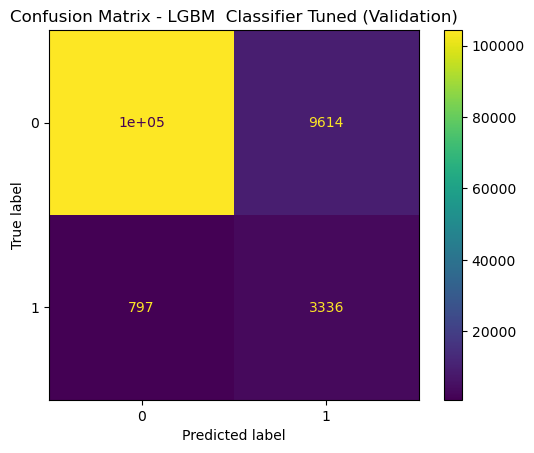

In [82]:
best_lgbm_model = lgbm_grid.best_estimator_


evaluate_model('LGBM  Classifier Tuned', best_lgbm_model, X_valid, y_valid)

## CatBoost Model

### Creating Dataset

In [56]:
cat_features_list = [
    "ProductCD",
    "P_emaildomain_group",
    "R_emaildomain_group",
    "P_emaildomain_suffix",
    "R_emaildomain_suffix",
    "browser_group",
    "os_group",
    "DeviceType",
    "card4",
    "card6",
]

In [57]:
X_cat = train[baseline_features].copy()
y_cat = train['isFraud'].copy()

In [58]:
for col in cat_features_list:
    X_cat[col] = X_cat[col].astype(str)

### Handling Missing Values

In [60]:
numeric_cols = [col for col in X_cat.columns if col not in cat_features_list]

for col in numeric_cols:
    X_cat[col]=X_cat[col].fillna(X_cat[col].median())

for col in cat_features_list:
    X_cat[col] = X_cat[col].astype(str).fillna('Missing')

### Train/Validation/Test Split

In [66]:
X_train_cat, X_temp_cat, y_train_cat, y_temp_cat = train_test_split(X_cat,y_cat,test_size=0.4,random_state=42,stratify=y_cat)
X_valid_cat, X_test_cat, y_valid_cat, y_test_cat = train_test_split(X_temp_cat, y_temp_cat, test_size=0.5, 
                                                                    random_state=42,stratify=y_temp_cat)


print(f'X Train Data: {X_train_cat.shape}')
print(f'X Validation Data: {X_valid_cat.shape}')
print(f'X Test Data: {X_test_cat.shape}')

print("\n Train Distribution")
print(y_train_cat.value_counts(normalize=True)*100)
print("\n Validation Distribution")
print(y_valid_cat.value_counts(normalize=True)*100)
print("\n Test Distribution")
print(y_test_cat.value_counts(normalize=True)*100)

X Train Data: (354324, 31)
X Validation Data: (118108, 31)
X Test Data: (118108, 31)

 Train Distribution
isFraud
0    96.500943
1     3.499057
Name: proportion, dtype: float64

 Validation Distribution
isFraud
0    96.50066
1     3.49934
Name: proportion, dtype: float64

 Test Distribution
isFraud
0    96.501507
1     3.498493
Name: proportion, dtype: float64


### CatBoost Feature Indices

In [67]:
cat_feature_indices = [X_train_cat.columns.get_loc(col) for col in cat_features_list]
cat_feature_indices

[2, 13, 14, 15, 16, 18, 19, 20, 6, 8]

## CatBoost Starter Model

In [69]:
cat_model = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=6, loss_function='Logloss', 
                               eval_metric='AUC', verbose=100, random_state=42)

cat_model.fit(X_train_cat, y_train_cat, cat_features=cat_feature_indices)

0:	total: 218ms	remaining: 1m 5s
100:	total: 13.1s	remaining: 25.8s
200:	total: 26.4s	remaining: 13s
299:	total: 39.6s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.05, loss_function='Logloss', random_state=42, verbose=100)

Model: CatBoost Native Categorical
Dataset: Validation
Accuracy: 0.974159244081688
Precision: 0.8740484429065744
Recall: 0.3055891604161626
F1 Score: 0.4528504840444604
ROC AUC: 0.8819217818247377

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.87      0.31      0.45      4133

    accuracy                           0.97    118108
   macro avg       0.92      0.65      0.72    118108
weighted avg       0.97      0.97      0.97    118108



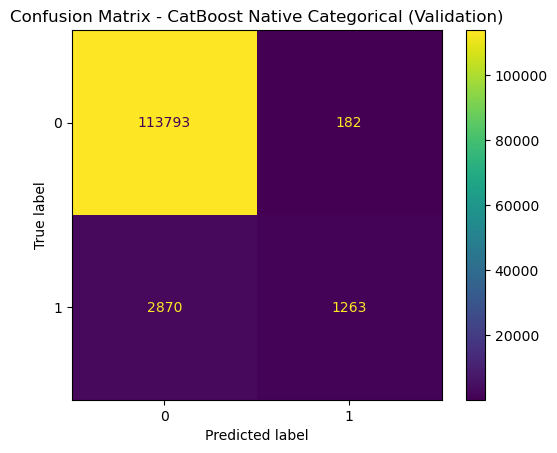

In [73]:
evaluate_model("CatBoost Native Categorical", cat_model, X_valid_cat, y_valid_cat)

## CatBoost GridSearchCV

In [75]:
cat_param_grid = {
    'depth':[4,6,8],
    'learning_rate':[0.03, 0.05, 0.1],
    'iterations':[200,300]
}

In [77]:
cat_grid = GridSearchCV(estimator=CatBoostClassifier(loss_function='Logloss', eval_metric='AUC', verbose=0, random_seed=42),
                        param_grid = cat_param_grid,
                        scoring='roc_auc',
                        cv=3,
                        n_jobs=-1
                       )

In [79]:
cat_grid.fit(X_test_cat, y_test_cat, cat_features=cat_feature_indices)

,estimator,"CatBoostClass...42, verbose=0)"
,param_grid,"{'depth': [4, 6, ...], 'iterations': [200, 300], 'learning_rate': [0.03, 0.05, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [83]:
print(f'CatBoost Best parameters \n {cat_grid.best_params_}')
print(f'CatBoost Best Score \n {cat_grid.best_score_}')

CatBoost Best parameters 
 {'depth': 8, 'iterations': 300, 'learning_rate': 0.1}
CatBoost Best Score 
 0.8891088310739353


In [85]:
best_cat_model = cat_grid.best_estimator_
best_cat_model

CatBoostClassifier(depth=8, eval_metric='AUC', iterations=300, learning_rate=0.1, loss_function='Logloss', random_seed=42, verbose=0)

Model: CatBoost Classifier
Dataset: Validation
Accuracy: 0.9755647373590274
Precision: 0.8794887401095557
Recall: 0.34962496975562546
F1 Score: 0.5003462603878116
ROC AUC: 0.8994837628242383

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.88      0.35      0.50      4133

    accuracy                           0.98    118108
   macro avg       0.93      0.67      0.74    118108
weighted avg       0.97      0.98      0.97    118108



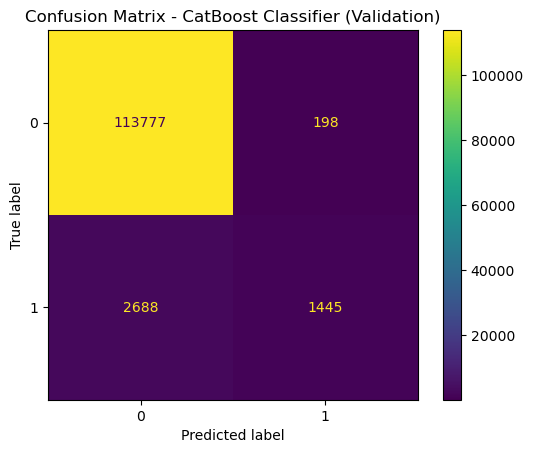

In [86]:
evaluate_model("CatBoost Classifier", best_cat_model, X_valid_cat, y_valid_cat, "Validation")

In [93]:
results_df = pd.DataFrame(model_results).drop_duplicates(subset='Model')
results_df.sort_values(by='ROC AUC', ascending=False)

,Model,Dataset,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,LGBM Classifier Tuned,Validation,0.911437,0.255184,0.798161,0.386726,0.935126
3,LightGMB Classifier,Validation,0.888399,0.208768,0.784660,0.329791,0.922170
0,XGBosst Classification Starter,Validation,0.976191,0.885131,0.367288,0.519152,0.920129
8,XG-Boost Classification Starter,Validation,0.976191,0.885131,0.367288,0.519152,0.920129
1,XGB Classifier Tuned,Validation,0.975201,0.868421,0.343334,0.492110,0.906710
10,CatBoost Classifier,Validation,0.975565,0.879489,0.349625,0.500346,0.899484
5,CatBoost Native Categorical,Validation,0.974159,0.874048,0.305589,0.452850,0.881922


[LightGBM] [Warning] Unknown parameter: max_dept
[LightGBM] [Warning] Unknown parameter: max_dept
Model: Final Tuned LGBM  Classifier
Dataset: Test
Accuracy: 0.9114369898736749
Precision: 0.25518415351284435
Recall: 0.7981606969990319
F1 Score: 0.38672607879924953
ROC AUC: 0.9351259352948136

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95    113976
           1       0.26      0.80      0.39      4132

    accuracy                           0.91    118108
   macro avg       0.62      0.86      0.67    118108
weighted avg       0.97      0.91      0.93    118108



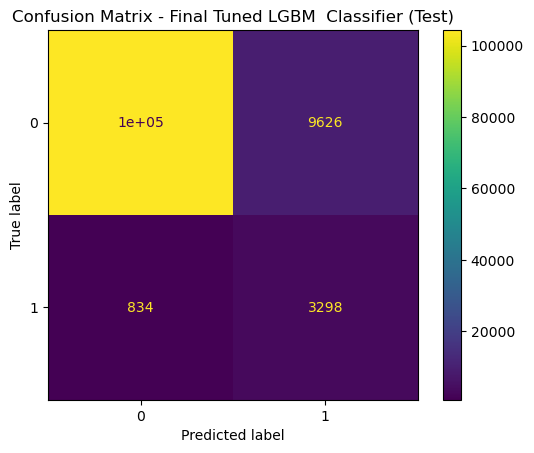

In [94]:
final_model = best_lgbm_model

evaluate_model('Final Tuned LGBM  Classifier', best_lgbm_model, X_test, y_test, dataset_name='Test')

## Feature Importance

In [99]:
feature_importance = pd.DataFrame({"Feature":X_train.columns, "Importance":final_model.feature_importances_})\
    .sort_values('Importance', ascending=False).head(20)
feature_importance

,Feature,Importance
3,card1,1383
4,card2,1006
9,addr1,908
23,C13,763
24,D1,700
26,D15,678
28,TransactionAmt_to_std_card1,641
21,C1,594
0,TransactionAmt,511
25,D10,509


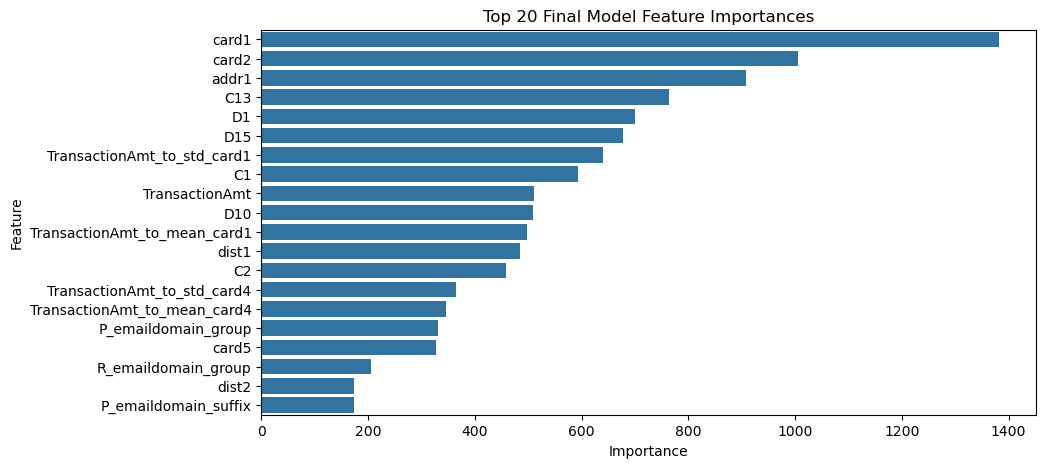

In [102]:
plt.figure(figsize=(10,5))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Top 20 Final Model Feature Importances')
plt.show()

## SHAP

In [104]:
!pip install shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.6/556.6 kB 3.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 6.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 8.1 MB/s  0:00:04 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]


In [108]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

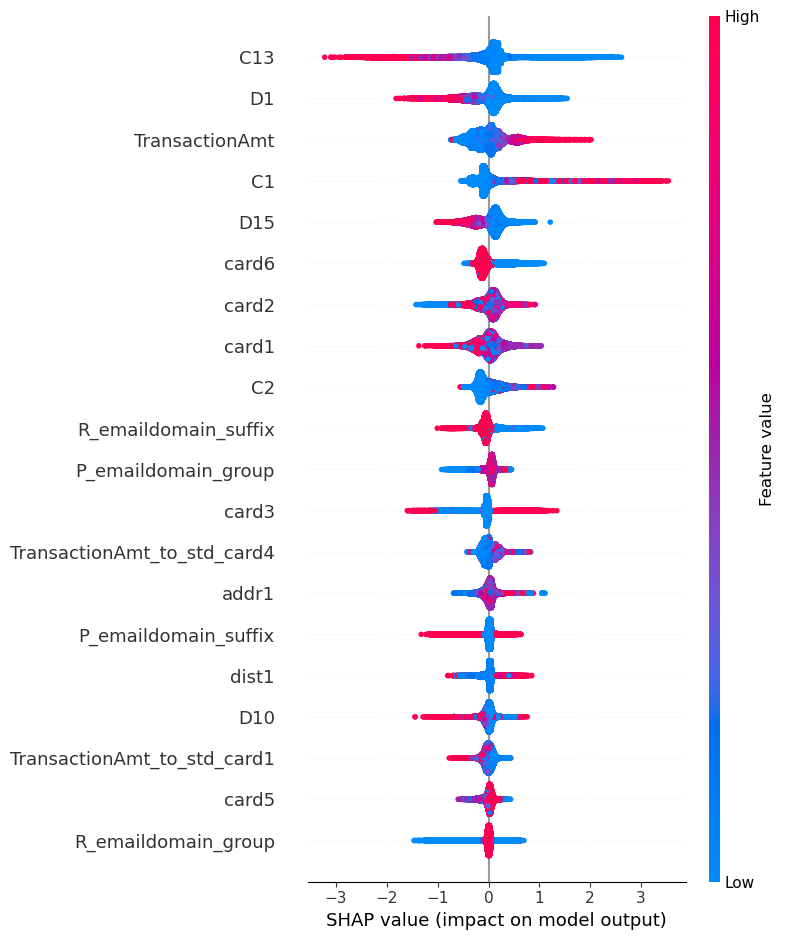

In [111]:
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

In [112]:
from sklearn.ensemble import IsolationForest

In [122]:
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.035, #Fraud rate is about 3.5%
    n_jobs=-1,
    random_state=42
)

In [128]:
iso_model.fit(X_train)


,n_estimators,200
,max_samples,'auto'
,contamination,0.035
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


In [134]:
iso_pred = iso_model.predict(X_test)
print(type(iso_pred))
print(iso_pred.shape)
print(np.unique(iso_pred, return_counts=True))

<class 'numpy.ndarray'>
(118108,)
(array([-1,  1]), array([  4178, 113930]))


In [135]:
iso_pred_binary = np.where(iso_pred == -1, 1, 0)

print(type(iso_pred_binary))
print(iso_pred_binary.shape)
print(np.unique(iso_pred_binary, return_counts=True))

<class 'numpy.ndarray'>
(118108,)
(array([0, 1]), array([113930,   4178]))


In [125]:
iso_pred_binary = np.where(iso_pred == -1, 1, 0)

Isolation Forest Results
Accuracy: 0.9349239678937922
Precision: 0.07467687888942078
Recall: 0.0755082284607938
F1 Score: 0.07509025270758123

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97    113976
           1       0.07      0.08      0.08      4132

    accuracy                           0.93    118108
   macro avg       0.52      0.52      0.52    118108
weighted avg       0.94      0.93      0.94    118108



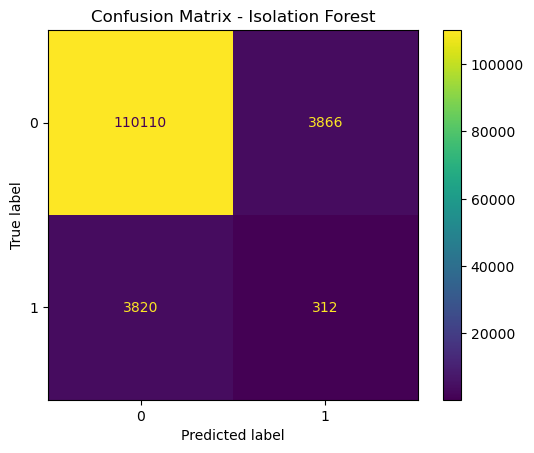

In [136]:
print("Isolation Forest Results")
print("=" * 40)

print("Accuracy:", accuracy_score(y_test, iso_pred_binary))
print("Precision:", precision_score(y_test, iso_pred_binary))
print("Recall:", recall_score(y_test, iso_pred_binary))
print("F1 Score:", f1_score(y_test, iso_pred_binary))

print("\nClassification Report:")
print(classification_report(y_test, iso_pred_binary))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    iso_pred_binary
)

plt.title("Confusion Matrix - Isolation Forest")
plt.show()